In [145]:
# Customer Churn Prediction System

## Phase 1: Data Understanding

### Author
##Sanisetty_Preetham

### Project Goal
###Predict whether a telecom customer is likely to churn based on historical customer behavior.

### Dataset
###IBM Telco Customer Churn Dataset

In [146]:
import numpy as np
import pandas as pd

In [147]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",1000)

In [148]:
df=pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [149]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [150]:
df.shape

(7043, 21)

In [151]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [152]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [154]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [155]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [156]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [157]:
duplicated_rows=df.duplicated().sum()
print(f"No of duplicated rows,{duplicated_rows}")

No of duplicated rows,0


In [158]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [159]:
df['TotalCharges'].head(20)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [160]:
blank_spaces = (df["TotalCharges"] == " ").sum()
print(f"No of blank spaces are:{blank_spaces}")

No of blank spaces are:11


In [161]:
df.nunique() # where it returns the no of categories present in each column.

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [162]:
categorical_columns = df.select_dtypes(include ="object").columns   #This line returns only column names

for column in categorical_columns:
    print("*"*70)
    print(df[column].value_counts())
    print()                                  #Where it returns like nunique(),but with categories names

**********************************************************************
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

**********************************************************************
gender
Male      3555
Female    3488
Name: count, dtype: int64

**********************************************************************
Partner
No     3641
Yes    3402
Name: count, dtype: int64

**********************************************************************
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

**********************************************************************
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

**********************************************************************
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: co

In [163]:
df['Churn'].value_counts(normalize=True)*100 #It returns the percentage form of each category in column

,proportion
Churn,
No,73.463013
Yes,26.536987


In [164]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [165]:
df_clean = df.copy()

In [166]:
df_clean[df_clean["TotalCharges"] ==  " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [167]:
df_clean["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

In [168]:
df_clean.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [169]:
df_clean["TotalCharges"]=pd.to_numeric(df_clean["TotalCharges"],errors="coerce")

In [170]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [171]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [172]:
df_clean["TotalCharges"].isnull()

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [173]:
df_clean = df_clean.dropna()

In [174]:
df_clean.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [175]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [176]:
df_clean.to_csv("customer_churn_clean.csv", index=False)

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
plt.style.use("ggplot")
plt.rcParams["figure.figsize"]=(8,5)

In [179]:
df_clean["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


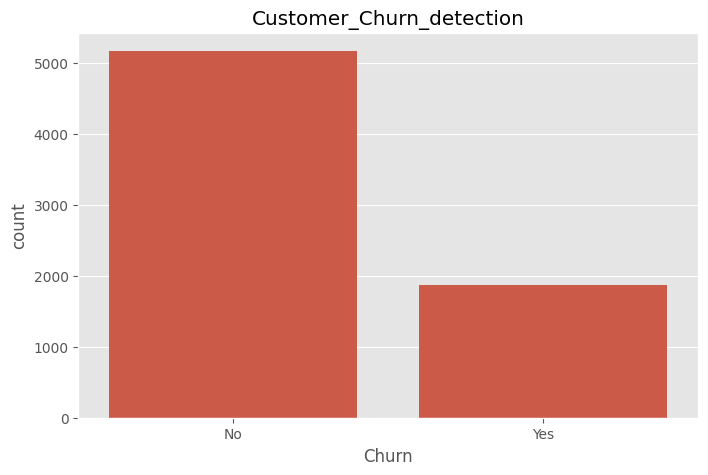

In [180]:
sns.countplot(data=df_clean,x="Churn")
plt.title("Customer_Churn_detection")
plt.show()

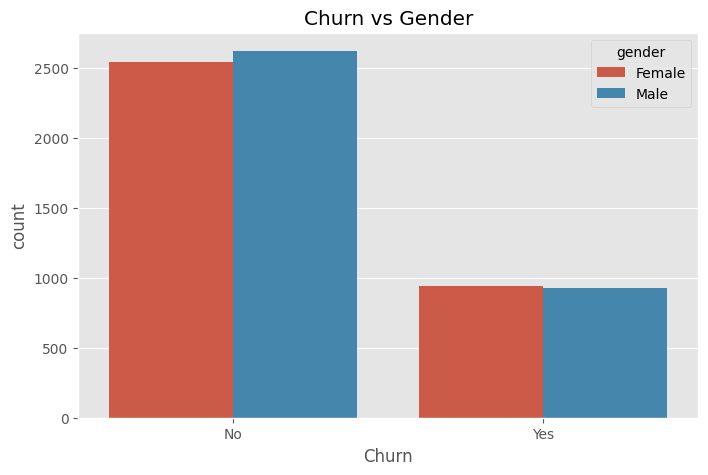

In [181]:
sns.countplot(data=df_clean,x="Churn",hue="gender")
plt.title("Churn vs Gender")
plt.show()

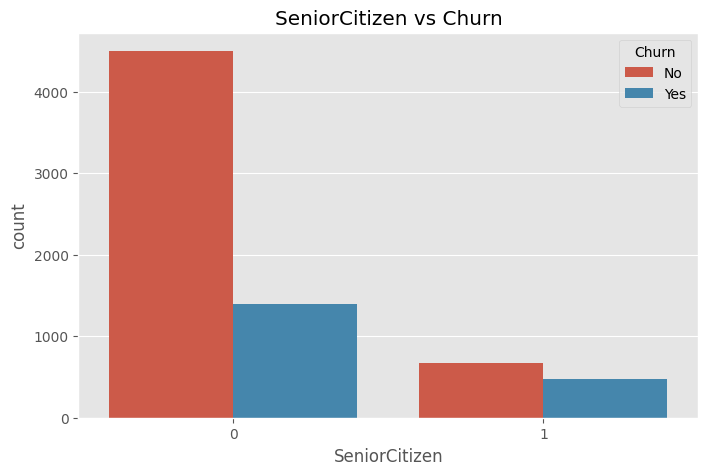

In [182]:
sns.countplot(data=df_clean,x="SeniorCitizen",hue="Churn")
plt.title("SeniorCitizen vs Churn")
plt.show()

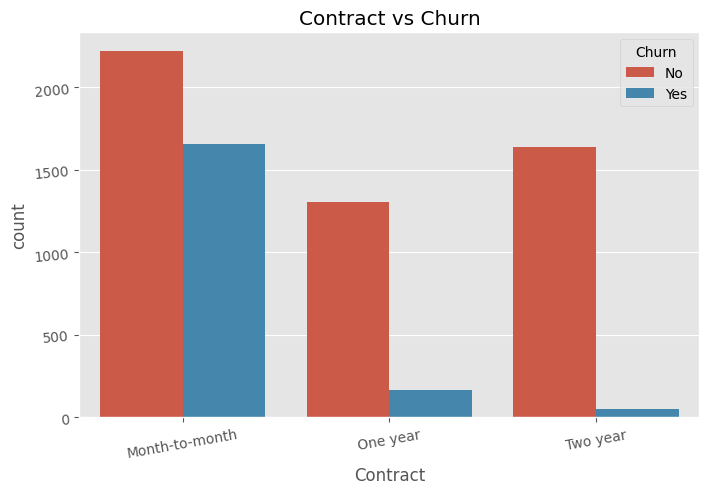

In [183]:
sns.countplot(data=df_clean,x="Contract",hue="Churn")
plt.title("Contract vs Churn")
plt.xticks(rotation=10)
plt.yticks(rotation=5)
plt.show()

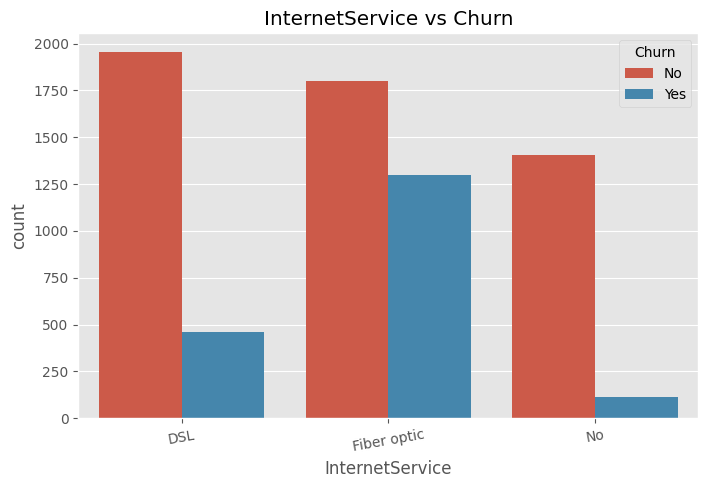

In [184]:
sns.countplot(df_clean,x="InternetService",hue="Churn")
plt.title("InternetService vs Churn")
plt.xticks(rotation=10)
plt.show()

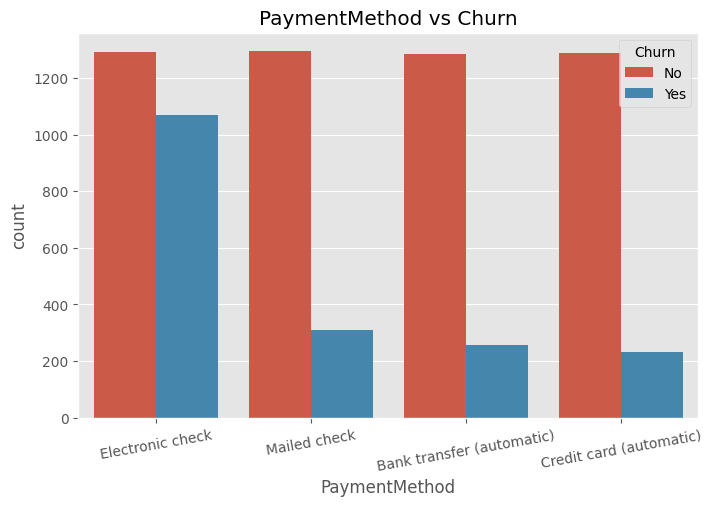

In [185]:
sns.countplot(data=df_clean,x="PaymentMethod",hue="Churn")
plt.title("PaymentMethod vs Churn")
plt.xticks(rotation=10)
plt.show()

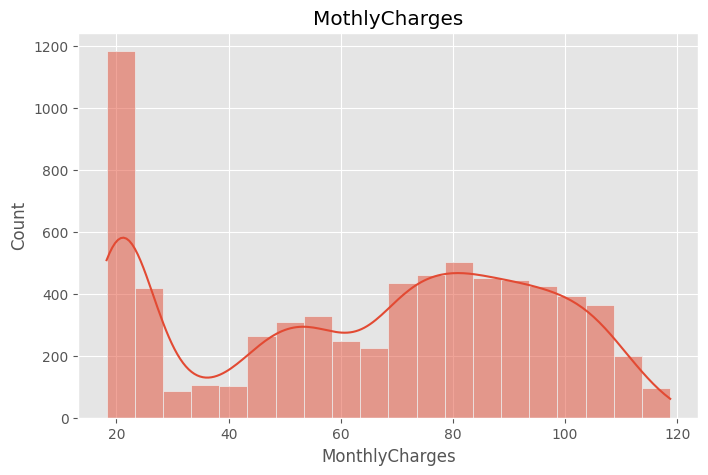

In [186]:
sns.histplot(df_clean["MonthlyCharges"],bins=20,kde=True)
plt.title("MothlyCharges")
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

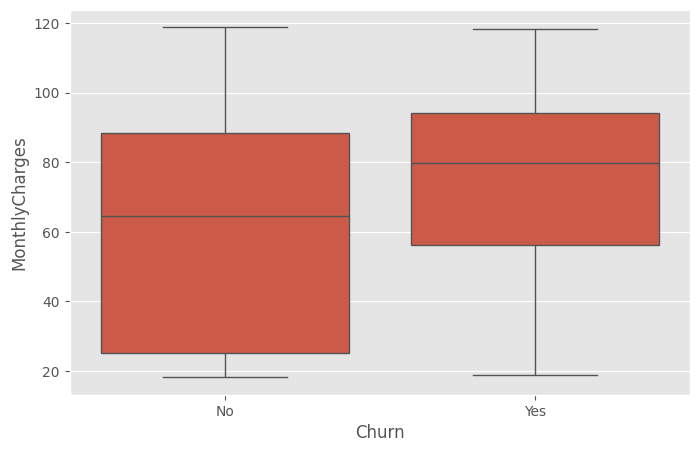

In [187]:
sns.boxplot(data=df_clean,y="MonthlyCharges",x="Churn")

<Axes: xlabel='Churn', ylabel='tenure'>

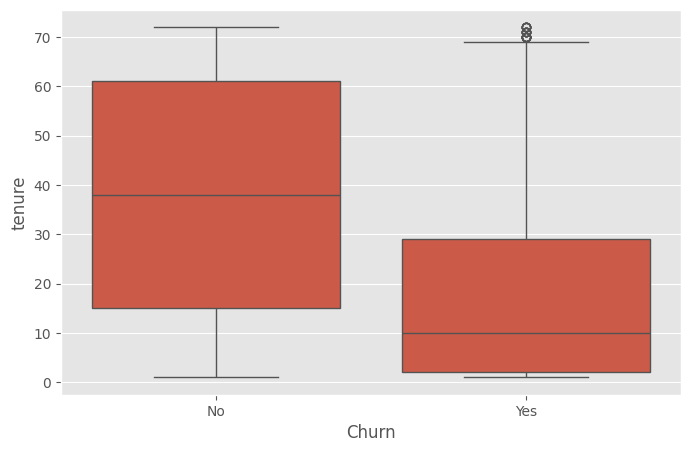

In [188]:
sns.boxplot(data=df_clean,y="tenure",x="Churn")

In [189]:
numeric_df = df_clean.select_dtypes(include=["int64","float64"])

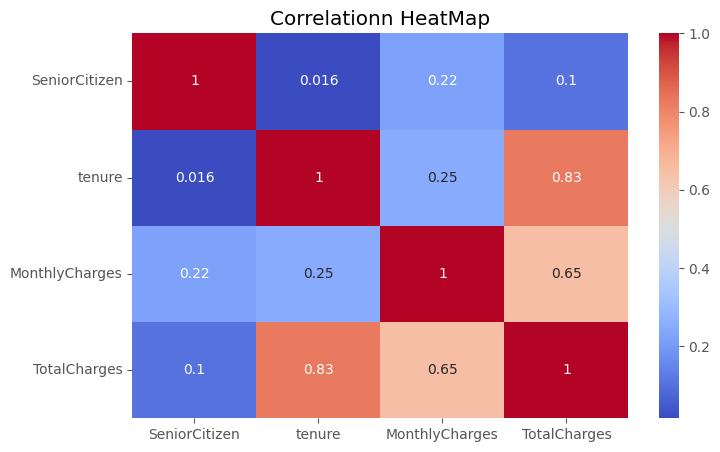

In [190]:
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlationn HeatMap")
plt.show()

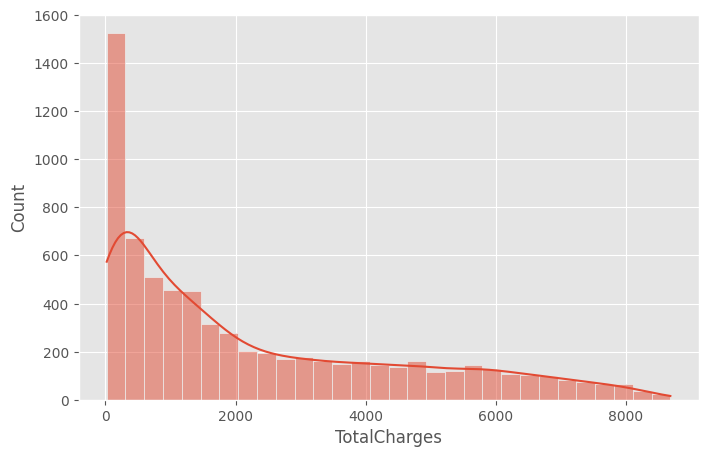

In [191]:
sns.histplot(data=df_clean,x="TotalCharges",bins=30,kde=True)
plt.show()

In [192]:
df_model=df_clean.drop("customerID",axis=1)

In [193]:
x=df_model.drop("Churn",axis=1)
y=df_model["Churn"].map({"Yes":1,"No":0})

In [194]:
categorical_columns=x.select_dtypes(include="object").columns
numerical_columns=x.select_dtypes(include=["int64","float64"]).columns
print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], dtype='object')


In [195]:
print(numerical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [196]:
binary_columns=["Partner","Dependents","PhoneService","PaperlessBilling"]
for col in binary_columns:
    x[col]=x[col].map({"Yes":1,"No":0})

In [197]:
x["gender"]=x["gender"].map({"Male":1,"Female":0})

In [198]:
x.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50


In [199]:
x=pd.get_dummies(x,drop_first=True)

In [200]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [201]:
y = y.map({"No": 0, "Yes": 1})

In [202]:
print(y.value_counts(dropna=False))

Churn
NaN    7032
Name: count, dtype: int64


In [203]:
print(df_clean["Churn"].unique())

['No' 'Yes']


In [204]:
y=df_clean["Churn"]

In [205]:
y=y.map({"No":0,"Yes":1})

In [206]:
print(y.value_counts(dropna=False))

Churn
0    5163
1    1869
Name: count, dtype: int64


In [207]:
print(x.shape)
print(y.shape)

(7032, 30)
(7032,)


In [208]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [209]:
x_train,y_train,x_test,y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [210]:
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

x_train (5625, 30)
x_test (5625,)
y_train (1407, 30)
y_test (1407,)


In [211]:
x=df_clean.drop(["Churn","customerID"],axis=1)
y=df_clean["Churn"]

In [212]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [213]:
print(type(x_train))
print(type(x_test))
print(type(y_train))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [214]:
x_train["gender"]=x_train["gender"].map({"Male":1,"Female":0})

In [215]:
categorical_columns=x_train.select_dtypes(include="object").columns
print(categorical_columns)

Index([], dtype='object')


In [216]:
x_train=pd.get_dummies(x_train,columns=categorical_columns,drop_first=True)

In [217]:
x_test=pd.get_dummies(x_test,columns=categorical_columns,drop_first=True)

In [218]:
x_train,x_test=x_train.align(x_test,join="left",axis=1,fill_value=0)

In [219]:
print(x_train.dtypes.value_counts())

bool       21
int64       6
float64     3
Name: count, dtype: int64


In [220]:
print(x_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [221]:
x_train.isna().sum().sort_values(ascending=False)

,0
gender,5625
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
MultipleLines_No phone service,0


In [222]:
x_test.isna().sum().sort_values(ascending=False)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
MultipleLines_No phone service,0


In [223]:
print("training Nan:",x_train.isna().sum().sum())
print("testing Nan:",x_test.isna().sum().sum())

training Nan: 5625
testing Nan: 0


In [224]:
x_train.columns[x_train.isna().any()]

Index(['gender'], dtype='object')

In [225]:
print(x["gender"].head())

0    Female
1      Male
2      Male
3      Male
4    Female
Name: gender, dtype: object


In [226]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [227]:
x_train=pd.get_dummies(x_train,drop_first=True)
x_test=pd.get_dummies(x_test,drop_first=True)

In [228]:
x_train,x_test=x_train.align(x_test,join="left",axis=1,fill_value=0)

In [229]:
print([col for col in x_train.columns if "gender" in col.lower()])

['gender_Male']


In [230]:
print(x_train["gender_Male"].head())

1413     True
7003     True
3355    False
4494     True
3541    False
Name: gender_Male, dtype: bool


In [231]:
from sklearn.preprocessing import StandardScaler

In [232]:
numerical_columns = ["tenure","MonthlyCharges","TotalCharges"]

scaler = StandardScaler()

x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])

x_test[numerical_columns] = scaler.transform(x_test[numerical_columns])

In [233]:
print(x_train[numerical_columns].head())

        tenure  MonthlyCharges  TotalCharges
1413  1.321816        0.981556      1.659900
7003 -0.267410       -0.971546     -0.562252
3355  1.444064        0.837066      1.756104
4494 -1.204646        0.641092     -0.908326
3541  0.669826       -0.808787     -0.101561


In [234]:
from sklearn.linear_model import LogisticRegression

In [285]:
lr_pipeline = LogisticRegression()

In [286]:
lr_pipeline.fit(x_train,y_train)


LogisticRegression()

In [237]:
y_pred = pd.Series(lr_pipeline.predict(x_test))

In [238]:
y_pred = y_pred.map({"Yes":1,"No":0})

In [239]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [240]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [241]:
preprocessor = ColumnTransformer(transformers=[("numerical",StandardScaler(),numerical_columns),
                                                ("categorical",OneHotEncoder(handle_unknown="ignore",drop="first"),categorical_columns)])

In [242]:
lr_pipeline = Pipeline([("preprocessor",preprocessor),("classifier",LogisticRegression(max_iter=1000))])

In [243]:
y_test=y_test.map({"Yes":1,"No":0})

In [244]:
print(y_test.isna())

974     False
619     False
4289    False
3721    False
4533    False
        ...  
4829    False
5176    False
2750    False
4432    False
2091    False
Name: Churn, Length: 1407, dtype: bool


In [245]:
print("Acccuracy:",accuracy_score(y_test,y_pred))

Acccuracy: 0.8045486851457001


In [246]:
print("Precision:", precision_score(y_test, y_pred,pos_label=1))

Precision: 0.6504559270516718


In [247]:
print("Recall:", recall_score(y_test, y_pred,pos_label=1))

Recall: 0.5721925133689839


In [248]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[918, 115],
       [160, 214]])

In [249]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [250]:
from sklearn.metrics import confusion_matrix

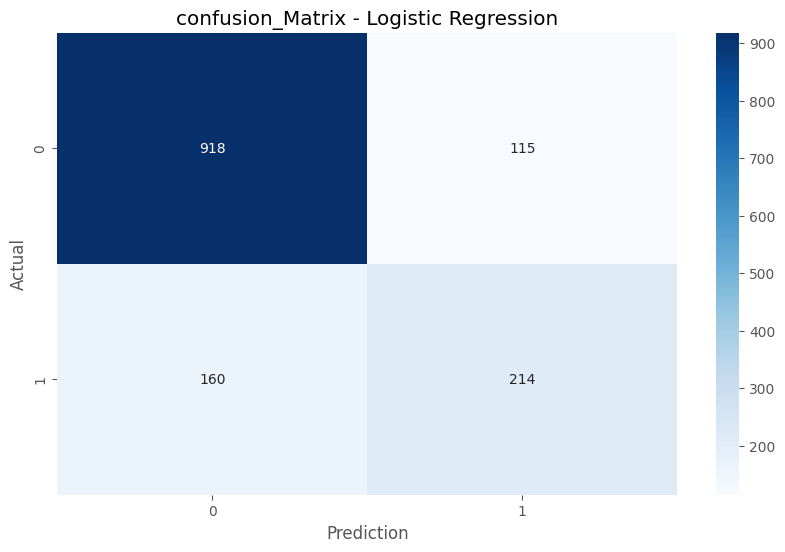

In [251]:
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("confusion_Matrix - Logistic Regression")
plt.show()

In [252]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [253]:
numerical_columns=["tenure","MonthlyCharges","TotalCharges"]
categorical_columns=["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"]

In [254]:
#preprocessor = ColumnTransformer([
   # ("name1", transformer1, columns1),
   # ("name2", transformer2, columns2)
#])

In [255]:
preprocessor=ColumnTransformer(transformers=[("numerical",StandardScaler(),numerical_columns),
                                            ("categorical",OneHotEncoder(handle_unknown="ignore", drop="first"),categorical_columns)])

In [256]:
dt_pipeline = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeClassifier(random_state=42,max_depth=5))])

In [257]:
print(dt_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
       

In [258]:
print(x_train.shape)

(5625, 30)


In [259]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [260]:
print(df[["tenure", "MonthlyCharges","TotalCharges"]].isna().sum())

tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64


In [261]:
df=df.dropna().copy()

In [262]:
y=df["Churn"].map({"Yes":1,"No":0})

In [263]:
X_train,X_test,Y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [264]:
dt_pipeline.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [265]:
dt_pred=dt_pipeline.predict(X_test)

In [266]:
print("Decision Tree")
print(classification_report(y_test,dt_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [267]:
from sklearn.ensemble import RandomForestClassifier

In [268]:
rf_pipeline=Pipeline(steps=[("preprocessor",preprocessor),
                            ("model",RandomForestClassifier(n_estimators=200,random_state=42,max_depth=8,n_jobs=-1))])

In [269]:
rf_pipeline.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(max_depth=8, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [270]:
rf_pred=rf_pipeline.predict(X_test)

In [271]:
print("random Forest")
print(classification_report(y_test,rf_pred))

random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [272]:
%pip install xgboost

In [273]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [274]:
xgb_pipeline=Pipeline(steps=[("preprocessor",preprocessor),
                            ("model",XGBClassifier(random_state=42,n_estimators=200,max_depth=4,learning_rate=0.05,evaluation_metric="logloss"))])

In [275]:
xgb_pipeline.fit(X_train,Y_train)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [11:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "evaluation_metric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport...
                               evaluation_metric='logloss', feature_types=None,
                               feature_weights=None, gamma=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None, ...))])

In [276]:
xgb_pred=xgb_pipeline.predict(X_test)

In [277]:
print("XGB Boost Classifier")
print(classification_report(y_test,xgb_pred))

XGB Boost Classifier
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [278]:
# Convert Yes/No predictions to 0/1
y_pred_lr = pd.Series(y_pred).map({"No": 0, "Yes": 1}).values
y_pred_dt = pd.Series(dt_pred).map({"No": 0, "Yes": 1}).values
y_pred_rf = pd.Series(rf_pred).map({"No": 0, "Yes": 1}).values
y_pred_xgb = pd.Series(xgb_pred).map({"No": 0, "Yes": 1}).values

In [279]:
y_pred_lr=pd.Series(y_pred).map({"No":0,"Yes":1}).to_numpy()
y_pred_lr

array([nan, nan, nan, ..., nan, nan, nan])

In [280]:
y_pred_lr=pd.Series(y_pred).replace({"No":0,"Yes":1})

In [281]:
y_pred_dt=dt_pred
y_pred_rf=rf_pred
y_pred_xgb=xgb_pred

In [282]:
#Model Comparision Table

print("MODEL COMPARISION TABLE")
results=[]

models={
    "Logistic Regression":y_pred_lr,
    "Decision Tree Classifier":y_pred_dt,
    "Random Forest Classifier":y_pred_rf,
    "XGB Boost Classifier":y_pred_xgb
}

for name,predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })
results_df=pd.DataFrame(results)
results_df.sort_values(by="F1 Score",ascending=False)

MODEL COMPARISION TABLE


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819
1,Decision Tree Classifier,0.780384,0.587131,0.585561,0.586345
3,XGB Boost Classifier,0.793888,0.632075,0.537433,0.580925
2,Random Forest Classifier,0.785359,0.625874,0.478610,0.542424


In [283]:
from sklearn.metrics import roc_auc_score

In [287]:
lr_prob=lr_pipeline.predict_proba(x_test)[:,1]
dt_prob=dt_pipeline.predict_proba(X_test)[:,1]
rf_prob=rf_pipeline.predict_proba(X_test)[:,1]
xgb_prob=xgb_pipeline.predict_proba(X_test)[:,1]

In [288]:
print("Logistic Regression ROC_AUC_Score:",roc_auc_score(y_test,lr_prob))
print("Decision Tress ROC_AUC_Score:",roc_auc_score(y_test,dt_prob))
print("Random Forest Classifier ROC_AUC_Score:",roc_auc_score(y_test,rf_prob))
print("XGB Boost ROC_AUC_Score:",roc_auc_score(y_test,xgb_prob))

Logistic Regression ROC_AUC_Score: 0.8360714082341553
Decision Tress ROC_AUC_Score: 0.8176020210072941
Random Forest Classifier ROC_AUC_Score: 0.8357802154567715
XGB Boost ROC_AUC_Score: 0.8376192596197152


In [289]:
n_estimators=200
max_depth=8

In [290]:
from sklearn.model_selection import GridSearchCV

In [291]:
rf_param_grid={
    "model__n_estimators":[100,200,300],
    "model__max_depth":[4,6,8,10],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4]
}

In [292]:
("model",RandomForestClassifier(...))

('model', RandomForestClassifier(n_estimators=Ellipsis))

In [293]:
rf_grid=GridSearchCV(estimator=rf_pipeline,param_grid=rf_param_grid,cv=5,scoring="f1",n_jobs=-1)

In [294]:
rf_grid.fit(X_train,Y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'De...
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(max_depth=8,
                                                               n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [4, 6, 8, 10],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='f1')

In [295]:
print("Best_Parameters")
print(rf_grid.best_params_)

Best_Parameters
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}


In [296]:
print("Best CV f1_score")
print(rf_grid.best_score_)

Best CV f1_score
0.5784645115373711


In [297]:
best_rf=rf_grid.best_estimator_

In [298]:
rt_tuned_pred = best_rf.predict(X_test)

In [299]:
print("Tuned Random Forest")
print("Accuracy",accuracy_score(rt_tuned_pred,y_test))
print("Precision",precision_score(rt_tuned_pred,y_test))
print("Reacall",recall_score(rt_tuned_pred,y_test))
print("F1 Score",f1_score(rt_tuned_pred,y_test))

Tuned Random Forest
Accuracy 0.7889125799573561
Precision 0.5053475935828877
Reacall 0.627906976744186
F1 Score 0.56


In [300]:
print("ROC_AUC_SCORE:",roc_auc_score(rt_tuned_pred,y_test))

ROC_AUC_SCORE: 0.730318768661424


In [301]:
print(classification_report(rt_tuned_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1106
           1       0.51      0.63      0.56       301

    accuracy                           0.79      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.81      0.79      0.80      1407



In [302]:
cm=confusion_matrix(rt_tuned_pred,y_test)

Text(0.5, 1.0, 'Tuned_Random_Forest CONFUSION_MATRIX')

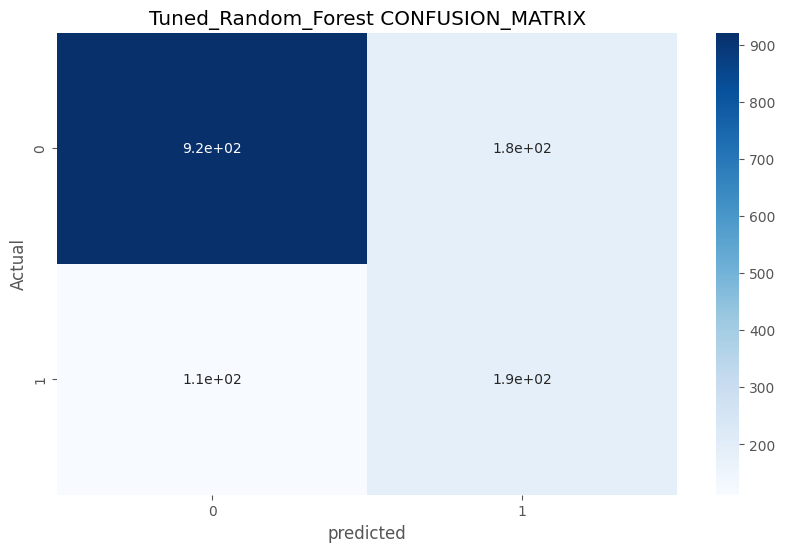

In [303]:
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Tuned_Random_Forest CONFUSION_MATRIX")

In [304]:
def convert_predictions(predictions):
    return pd.Series(predictions).map({
        "No": 0,
        "Yes": 1
    }).fillna(pd.Series(predictions)).astype(int).values

In [305]:
lr_pred = convert_predictions(lr_pipeline.predict(x_test))
dt_pred = convert_predictions(dt_pipeline.predict(X_test))
rf_pred = convert_predictions(rf_pipeline.predict(X_test))
xgb_pred = convert_predictions(xgb_pipeline.predict(X_test))
rf_tuned_pred = convert_predictions(best_rf.predict(X_test))

In [306]:
print("y_test:",pd.Series(y_test).unique())
print("lr:",pd.Series(lr_pred).unique())
print("dt:",pd.Series(dt_pred).unique())
print("rf:",pd.Series(rf_pred).unique())
print("xgb:",pd.Series(xgb_pred).unique())
print("rf_tuned:",pd.Series(rf_tuned_pred).unique())

y_test: [0 1]
lr: [0 1]
dt: [0 1]
rf: [0 1]
xgb: [0 1]
rf_tuned: [0 1]


In [307]:
print("y_test type:", type(y_test))
print("y_test values:", pd.Series(y_test).unique())

print("\nLR:")
print(type(lr_pipeline))
print(lr_pipeline.predict(x_test)[:10])

print("\nDT:")
print(type(dt_pipeline))
print(dt_pipeline.predict(X_test)[:10])

print("\nRF:")
print(type(rf_pipeline))
print(rf_pipeline.predict(X_test)[:10])

print("\nXGB:")
print(type(xgb_pipeline))
print(xgb_pipeline.predict(X_test)[:10])

y_test type: <class 'pandas.core.series.Series'>
y_test values: [0 1]

LR:
<class 'sklearn.linear_model._logistic.LogisticRegression'>
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No']

DT:
<class 'sklearn.pipeline.Pipeline'>
[0 1 0 0 0 0 0 0 1 0]

RF:
<class 'sklearn.pipeline.Pipeline'>
[0 1 0 0 0 0 0 0 1 0]

XGB:
<class 'sklearn.pipeline.Pipeline'>
[0 1 0 0 0 0 0 0 1 0]


In [308]:
best_model=best_rf

In [309]:
model = best_model.named_steps["model"]

In [310]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [311]:
featured_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [312]:
print("Number of features:",len(featured_names))

Number of features: 29


In [313]:
print(featured_names)

['numerical__tenure' 'numerical__MonthlyCharges' 'numerical__TotalCharges'
 'categorical__gender_Male' 'categorical__Partner_Yes'
 'categorical__Dependents_Yes' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes'
 'categorical__TechSupport_No internet service'
 'categorical__TechSupport_Yes'
 'categorical__StreamingTV_No internet service'
 'categorical__StreamingTV_Yes'
 'categorical__StreamingMovies_No internet service'
 'categorical__StreamingMovies_Yes' 'categorical__Contract_One year'
 'categorical__Contract_Two year' 'categorical__PaperlessBilling_Yes'
 'categorical__PaymentMethod_Credit ca

In [314]:
model.feature_importances_

array([0.17792039, 0.10796322, 0.16320073, 0.01133591, 0.01333048,
       0.01344614, 0.00430509, 0.00418785, 0.01405161, 0.08305763,
       0.012188  , 0.00979551, 0.03150593, 0.00741748, 0.01644309,
       0.01143822, 0.0102458 , 0.01201464, 0.02935818, 0.01156421,
       0.01104366, 0.01135883, 0.0112706 , 0.04294615, 0.07780179,
       0.01873908, 0.00871684, 0.06642035, 0.00693258])

In [315]:
importance_df=pd.DataFrame({"Feature":featured_names,"Importance":model.feature_importances_})

In [316]:
importance_df = importance_df.sort_values(by="Importance",ascending=False)

In [317]:
importance_df.head(15)

,Feature,Importance
0,numerical__tenure,0.177920
2,numerical__TotalCharges,0.163201
1,numerical__MonthlyCharges,0.107963
9,categorical__InternetService_Fiber optic,0.083058
24,categorical__Contract_Two year,0.077802
27,categorical__PaymentMethod_Electronic check,0.066420
23,categorical__Contract_One year,0.042946
12,categorical__OnlineSecurity_Yes,0.031506
18,categorical__TechSupport_Yes,0.029358
25,categorical__PaperlessBilling_Yes,0.018739


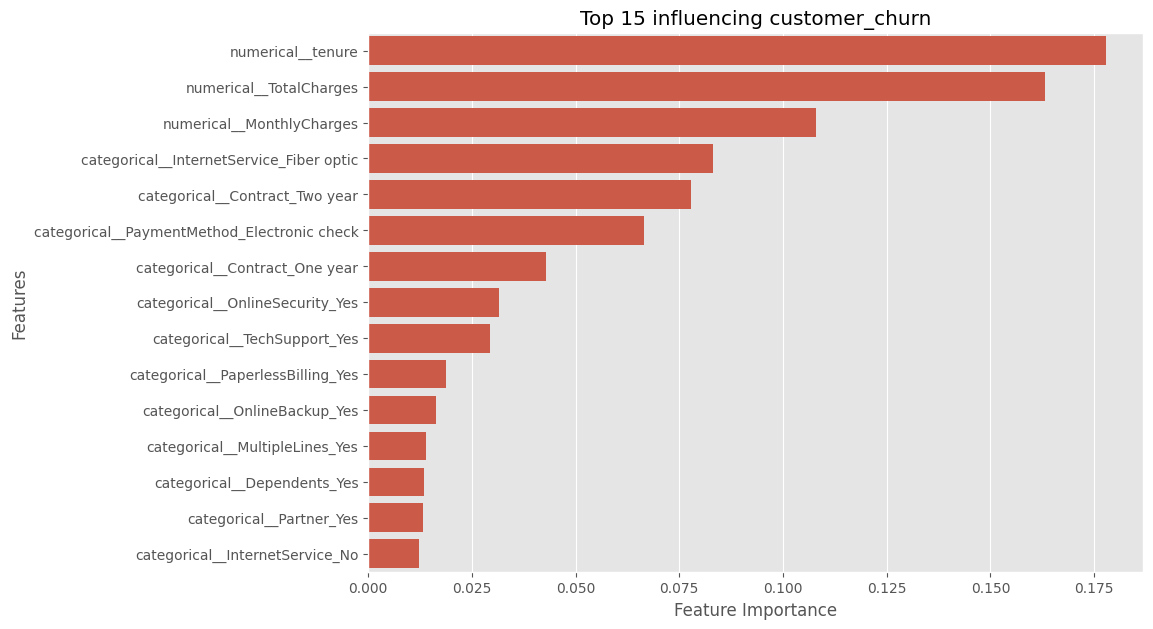

In [318]:
plt.figure(figsize=(10,7))
top_features = importance_df.head(15)

sns.barplot(data=top_features,x="Importance",y="Feature")

plt.title("Top 15 influencing customer_churn")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

In [319]:
customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.5,
    "TotalCharges": 427.5
}

In [320]:
customer_df = pd.DataFrame([customer])

In [321]:
prediction = best_model.predict(customer_df)

probability = best_model.predict_proba(customer_df)[:1]

In [322]:
print("Prediction",prediction[0])
print("Probability",probability[0])

Prediction 1
Probability [0.25282036 0.74717964]


In [323]:
if prediction[0] == 1:
    print("High Risk:Customer is likely to Churn")
else:
    print("Low Risk:Customer is unlikely to Churn")

High Risk:Customer is likely to Churn


In [324]:
print(f"Churn Probability: {probability[0][1] * 100:.2f}%")

Churn Probability: 74.72%


In [325]:
import joblib

In [326]:
joblib.dump(best_model,"customer_churn_model.pkl")

['customer_churn_model.pkl']

In [327]:
import os

In [328]:
print(os.path.exists("customer_churn_model.pkl"))

True


In [329]:
pip install fastapi uvicorn joblib

In [330]:
import fastapi

In [331]:
print(fastapi.__version__)

0.141.1


User sends customer details
        ↓
FastAPI receives them
        ↓
Pydantic validates the data
        ↓
Convert data → Pandas DataFrame
        ↓
Saved ML model makes prediction
        ↓
Calculate churn probability
        ↓
Determine Low / Medium / High risk
        ↓
Return JSON response

In [332]:
import os

print(os.listdir("/content"))

['.config', 'customer_churn_clean.csv', 'sample_data', 'customer_churn_model.pkl', 'api']


In [333]:
os.makedirs("/content/api", exist_ok=True)

open("/content/api/__init__.py", "w").close()

print("API folder created")

API folder created


In [334]:
print(os.path.exists("/content/customer_churn_model.pkl"))

True


In [335]:
joblib.dump(
    best_model,
    "/content/customer_churn_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [336]:
with open("/content/api/__init__.py", "w") as f:
    f.write("")

print("api folder:", os.path.exists("/content/api"))
print("init file:", os.path.exists("/content/api/__init__.py"))

api folder: True
init file: True


In [337]:
import os

# 1. Create the API folder
api_folder = "/content/api"
os.makedirs(api_folder, exist_ok=True)

# 2. Create __init__.py
with open("/content/api/__init__.py", "w") as f:
    f.write("")

# 3. FastAPI code
main_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(
    title="Customer Churn Prediction API",
    description="API for predicting telecom customer churn",
    version="1.0.0"
)

# Load trained model
model = joblib.load("/content/customer_churn_model.pkl")


class CustomerData(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float


@app.get("/")
def home():
    return {
        "message": "Customer Churn Prediction API is running"
    }


@app.post("/predict")
def predict_churn(customer: CustomerData):

    customer_dict = customer.model_dump()
    customer_df = pd.DataFrame([customer_dict])

    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0][1]

    if probability < 0.30:
        risk = "Low"
    elif probability < 0.60:
        risk = "Medium"
    else:
        risk = "High"

    return {
        "churn_prediction": int(prediction),
        "churn_probability": round(float(probability), 4),
        "risk_level": risk
    }
'''

# 4. Create main.py
with open("/content/api/main.py", "w") as f:
    f.write(main_code)

# 5. Verify
print("API folder exists:", os.path.exists("/content/api"))
print("main.py exists:", os.path.exists("/content/api/main.py"))
print("Model exists:", os.path.exists("/content/customer_churn_model.pkl"))

API folder exists: True
main.py exists: True
Model exists: True


In [338]:
joblib.load("customer_churn_model.pkl")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=2,
                                        min_samples_split=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [339]:
import os

print("Model exists:", os.path.exists("/content/customer_churn_model.pkl"))
print("API exists:", os.path.exists("/content/api/main.py"))

Model exists: True
API exists: True


In [341]:
import subprocess
import time

server = subprocess.Popen(
    [
        "python", "-m", "uvicorn",
        "api.main:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    cwd="/content"
)

time.sleep(5)

print("FastAPI server started")

FastAPI server started


In [342]:
import requests

response = requests.get("http://127.0.0.1:8000/")

print(response.status_code)
print(response.json())

200
{'message': 'Customer Churn Prediction API is running'}
